# 02 | Training Efficiency Analysis and Grad-CAM Diagnostics

This notebook profiles the `Food-101` input pipeline and then inspects the best `MobileNetV3-Large` model with `Grad-CAM` so we can connect throughput choices with prediction behavior.

**Notebook outline**
- Rebuild the training and evaluation transforms used throughout the project
- Benchmark how `num_workers`, `batch_size`, `pin_memory`, and `prefetch_factor` affect data-loading efficiency
- Reload the best Stage 2 `MobileNetV3-Large` weights exported from Notebook 01
- Compare correct and incorrect test predictions with `Grad-CAM` overlays


In [ ]:
import gc
import os
import json
import numpy as np
import random
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision import models as tv_models
from torch.utils.data import DataLoader

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import importlib
import helper_utils
importlib.reload(helper_utils)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [21]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Profile Data-Loading Efficiency

Measure how key `DataLoader` settings change epoch time before we lock in an optimized training configuration.


In [ ]:
# Training-time image transforms.
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # Match ImageNet normalization because the backbones start from ImageNet weights.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transforms stay deterministic for fair evaluation.
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # Use the same ImageNet normalization as the pretrained backbone so
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [23]:
# Reuse the training transform pipeline for the training split.
trainset = datasets.Food101(root="../data", split="train", transform=TRAIN_TRANSFORM, download=False) 

# Quick dataset-level check
print("Train dataset size:", len(trainset))


Train dataset size: 75750


In [24]:
cpu_cores = os.cpu_count()
print(f"Number of available CPU cores: {cpu_cores}")

Number of available CPU cores: 14


### 1.1 Test `num_workers`

Start by varying the number of worker processes to see how much parallel data loading helps on the current hardware.


In [25]:
workers_to_test = [0, 2, 4, 8]

In [26]:
def experiment_workers(workers_to_test, trainset, device):
    # Initialize a dictionary to store the results
    worker_times = {}

    # Loop through each worker number you want to test
    for nw in workers_to_test:
        print(f"--- Testing Number of Workers = {nw} ---")
        
        # Create a new DataLoader instance for each specific test.
        loader = DataLoader(trainset, 
                            batch_size=64, 
                            shuffle=True,
                            # The 'num_workers' is set to the current value in the loop.
                            num_workers=nw
                        )
        
        # Handle potential runtime errors
        try:
            # Time the data loading for one epoch and save it to the dictionary
            worker_times[nw] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs (often from running out of shared memory)
            print(f"\n❌ ERROR with {nw} workers. Likely a shared memory issue.")
            worker_times[nw] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return worker_times

In [ ]:
# Run the experiment to measure data-loading time for different numbers of workers.
worker_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name='worker_times', 
    # The function that contains the experiment logic.
    experiment_fcn=experiment_workers, 
    # The worker counts to iterate over.
    cases=workers_to_test, 
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=True
)


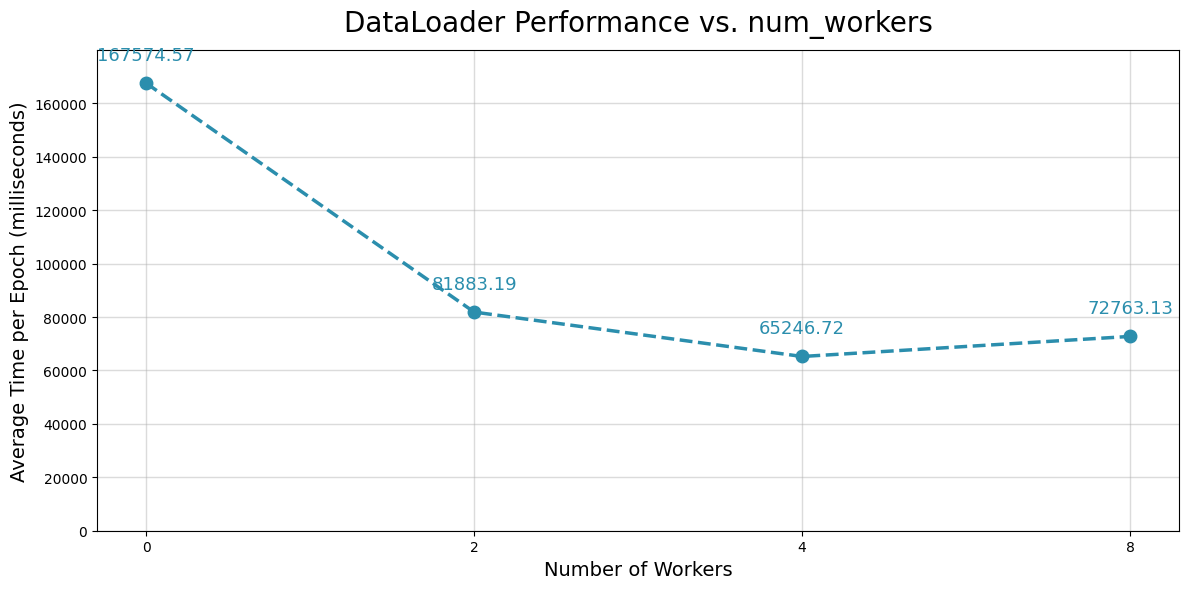

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. num_workers'}, xlabel='Number of Workers', ylabel='Average Time per Epoch (milliseconds)'>)

In [28]:
helper_utils.plot_performance_summary(
    worker_times, 
    title="DataLoader Performance vs. num_workers", 
    xlabel="Number of Workers", 
    ylabel="Average Time per Epoch (milliseconds)"
)

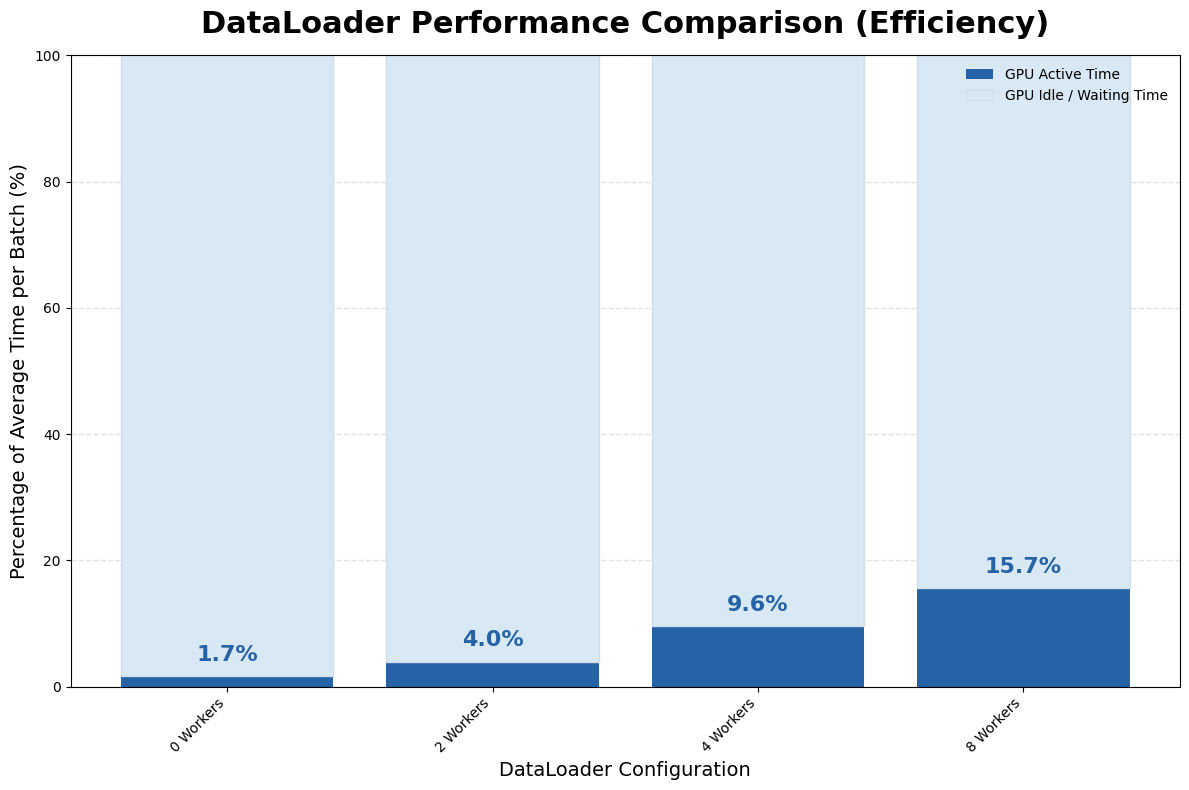

In [29]:
# Build one DataLoader per worker setting so their throughput can be compared side by side.
loaders_to_compare = {
    f"{nw} Workers": DataLoader(trainset, batch_size=64, num_workers=nw) 
    for nw in workers_to_test
}

# Pass the generated loaders to the plotting helper.
helper_utils.visualize_dataloader_efficiency(loaders_to_compare, device)

# Clean up and release memory.
del loaders_to_compare
gc.collect()

# Clear the PyTorch MPS cache to free up GPU memory.
if torch.mps.is_available():
    torch.mps.empty_cache()


### 1.2 Test `batch_size`

Next, compare batch sizes to understand the throughput versus memory trade-off for this pipeline.


In [30]:
batch_sizes_to_test = [ 32, 64, 128, 256]

In [31]:
def experiment_batch_sizes(batch_sizes_to_test, trainset, device):
    # Initialize a dictionary to store the results
    batch_size_times = {}

    # Loop through each batch size you want to test
    for bs in batch_sizes_to_test:
        print(f"--- Testing Batch Size = {bs} ---")
        
        # Create a new DataLoader instance for each specific test.
        loader = DataLoader(trainset, 
                            # The 'batch_size' is set to the current value in the loop.
                            batch_size=bs, 
                            shuffle=True,
                            num_workers=4 # Use the most efficient num_workers parameter
                        )
        
        # Handle potential runtime errors, especially out-of-memory
        try:
            # Time the data loading for one epoch and save it to the dictionary
            batch_size_times[bs] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs (often from running out of GPU memory),
            print(f"\n❌ ERROR with batch size {bs}. Likely a GPU memory issue.")
            batch_size_times[bs] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        # ensuring each test runs in a clean environment.
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory.
        if torch.mps.is_available():
            torch.mps.empty_cache()
        
    return batch_size_times

In [ ]:
# Run the experiment to measure data-loading time for different batch sizes.
batch_size_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="batch_size_times", 
    # The function that contains the experiment logic.
    experiment_fcn=experiment_batch_sizes,
    # The batch sizes to iterate over.
    cases=batch_sizes_to_test,
    # The dataset required by the experiment function.
    trainset=trainset,
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=True
)


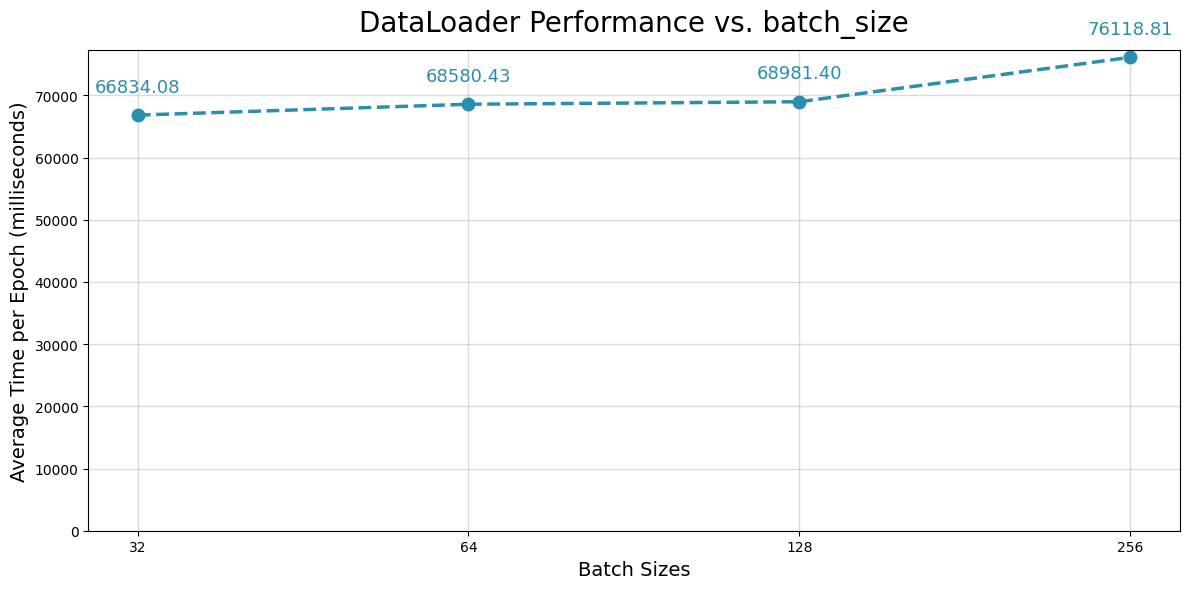

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. batch_size'}, xlabel='Batch Sizes', ylabel='Average Time per Epoch (milliseconds)'>)

In [33]:
helper_utils.plot_performance_summary(
    batch_size_times, 
    title="DataLoader Performance vs. batch_size", 
    xlabel="Batch Sizes", 
    ylabel="Average Time per Epoch (milliseconds)"
)

### 1.3 Test `pin_memory`

Check whether pinned host memory improves transfer efficiency enough to justify enabling it by default.


In [34]:
pin_memory_settings = [False, True]

In [35]:
def experiment_pin_memory(pin_memory_settings, trainset, device):
    # Initialize a dictionary to store the results
    pin_memory_times = {}

    # Loop through each pin_memory setting
    for setting in pin_memory_settings:
        print(f"--- Testing with pin_memory = {setting} ---")
        
        # Create a DataLoader with the current pin_memory setting
        loader = DataLoader(trainset,
                            batch_size=32, # Use the most efficient batch_size parameter
                            num_workers=4, # Use the most efficient num_workers parameter
                            shuffle=True,
                            # The 'pin_memory' is set to the current boolean value in the loop.
                            pin_memory=setting
                        )
        
        try:
            # Measure performance and store the result in the dictionary
            pin_memory_times[setting] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # Print an error message if an exception occurs
            print(f"\n❌ An error occurred with pin_memory = {setting}: {e}")
            pin_memory_times[setting] = float('inf')
            
        # --- Memory Cleanup for each iteration ---
        del loader
        gc.collect()
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return pin_memory_times

In [ ]:
# Run the experiment to measure data-loading time with pin_memory set to False or True.
pin_memory_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="pin_memory_times",
    # The function that contains the experiment logic.
    experiment_fcn=experiment_pin_memory,
    # The pin_memory settings to iterate over.
    cases=pin_memory_settings,
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=False
)


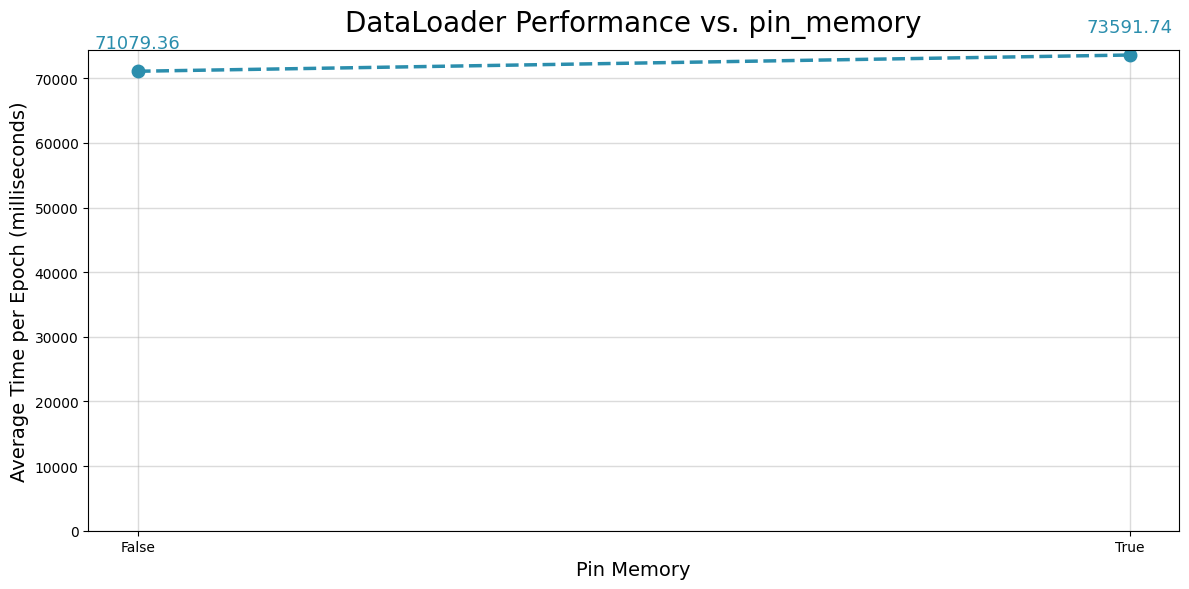

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. pin_memory'}, xlabel='Pin Memory', ylabel='Average Time per Epoch (milliseconds)'>)

In [37]:
helper_utils.plot_performance_summary(
    pin_memory_times, 
    title="DataLoader Performance vs. pin_memory", 
    xlabel="Pin Memory", 
    ylabel="Average Time per Epoch (milliseconds)"
)

### 1.4 Test `prefetch_factor`

Finally, vary `prefetch_factor` to see how aggressively each worker should prepare future batches.


In [38]:
# Define the list of prefetch_factor values to test
prefetch_factors_to_test = [2, 4, 6, 8]

In [39]:
def experiment_prefetch_factor(prefetch_factors_to_test, trainset, device):
    # Initialize a dictionary to store the results
    prefetch_factor_times = {}

    # Loop through each prefetch factor you want to test
    for pf in prefetch_factors_to_test:
        print(f"--- Testing prefetch_factor = {pf} ---")
        
        # Create a new DataLoader instance for each specific test, using the optimal settings
        loader = DataLoader(trainset, 
                            batch_size=32, # Use the most efficient batch_size parameter
                            shuffle=True, 
                            num_workers=4, # Use the most efficient num_workers parameter
                            pin_memory=False, # Use the most efficient pin_memory choice
                            # The 'prefetch_factor' is set to the current value in the loop.
                            prefetch_factor=pf
                        )
        
        # Handle potential runtime errors
        try:
            # Time the data loading for one epoch and save it to the dictionary
            prefetch_factor_times[pf] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs, record it.
            print(f"\n❌ ERROR with prefetch_factor {pf}: {e}")
            prefetch_factor_times[pf] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        # ensuring each test runs in a clean environment.
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory.
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return prefetch_factor_times

In [ ]:
# Run the experiment to measure data-loading time for different prefetch_factor values.
prefetch_factor_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="prefetch_factor_times", 
    # The function that contains the experiment logic.
    experiment_fcn=experiment_prefetch_factor,
    # The prefetch_factor values to iterate over.
    cases=prefetch_factors_to_test,
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=False
)


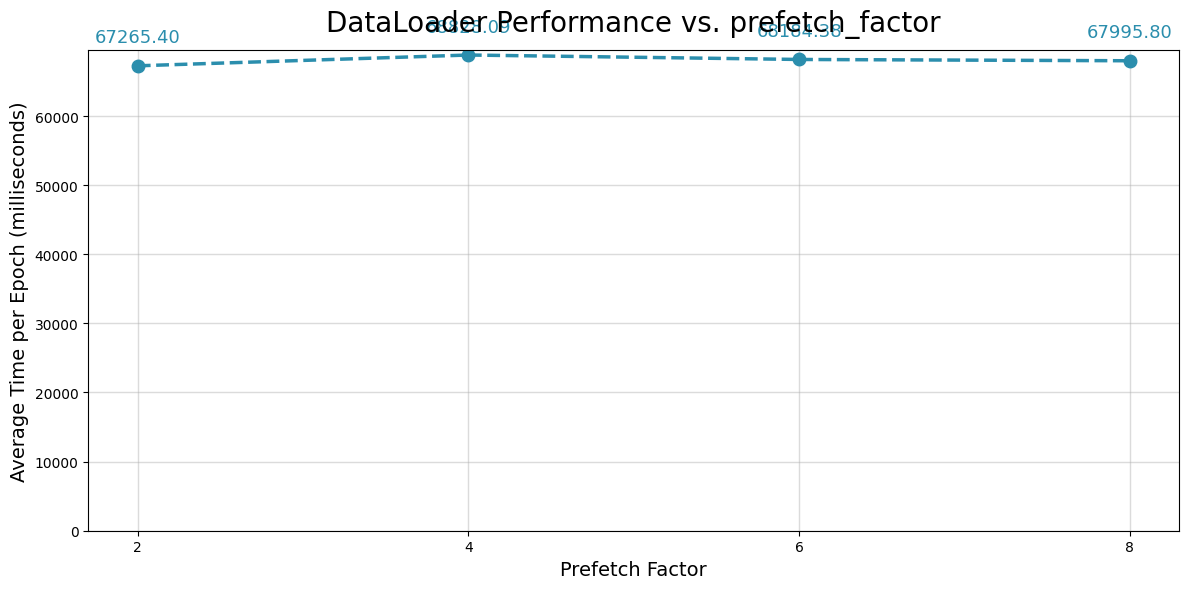

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. prefetch_factor'}, xlabel='Prefetch Factor', ylabel='Average Time per Epoch (milliseconds)'>)

In [41]:
helper_utils.plot_performance_summary(
    prefetch_factor_times, 
    title="DataLoader Performance vs. prefetch_factor", 
    xlabel="Prefetch Factor", 
    ylabel="Average Time per Epoch (milliseconds)"
)

## 2. Analyze Misclassifications with `Grad-CAM`

Load the best checkpoint exported in Notebook 01, sample both correct and incorrect test predictions, and visualize `Grad-CAM` heatmaps for the predicted class.


In [48]:
# Use the same deterministic transform as evaluation.
testset = datasets.Food101(root="../data", split="test", transform=VAL_TRANSFORM, download=False) 

print("Test dataset size:", len(testset))


Test dataset size: 25250


In [49]:
# Load the best MobileNetV3 checkpoint.
weights_path = Path("../artifacts/weights/food101_mobilenetv3_stage2_best_state_dict.pth")

# Rebuild the model before loading the state dict.
best_model = tv_models.mobilenet_v3_large(weights=None)

# Replace the classifier for Food-101.
num_ftrs = best_model.classifier[-1].in_features
new_classifier = nn.Linear(in_features=num_ftrs, out_features=101)
best_model.classifier[-1] = new_classifier

state_dict = torch.load(weights_path, map_location=device, weights_only=True)
best_model.load_state_dict(state_dict)

# Move to the active device and switch to eval mode.
best_model = best_model.to(device)
best_model.eval()

print(f"Loaded best_model weights from: {weights_path}")


Loaded best_model weights from: ../artifacts/weights/food101_mobilenetv3_stage2_best_state_dict.pth


### 2.1 Analyze Misclassifications

Start by sampling both correct and incorrect test predictions so we can inspect the model's failure modes before explaining them with `Grad-CAM`.


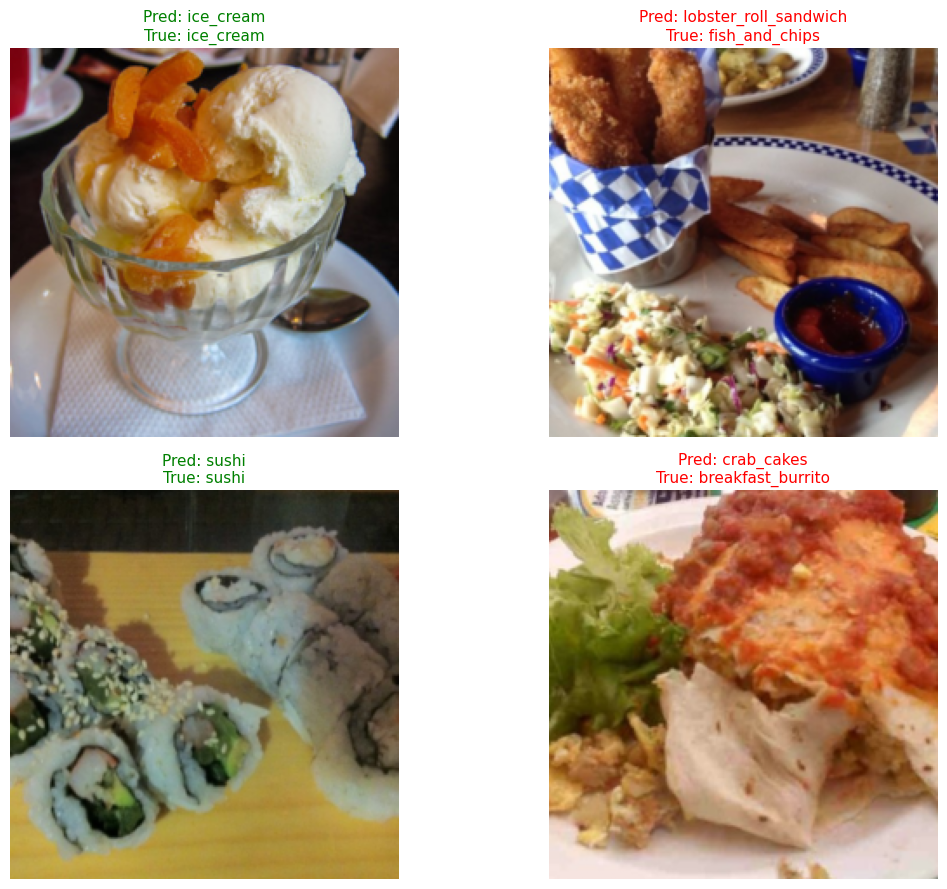

In [72]:
# Sample a few correct and incorrect test predictions.
fig, axes, examples = helper_utils.show_test_prediction_examples(
    best_model,
    testset,
    num_correct=2,
    num_incorrect=2,
    batch_size=32,
    random_seed=SEED,
)


### 2.2 Show `Grad-CAM` Heatmaps

Use the sampled examples to generate `Grad-CAM` overlays for the predicted class and compare where the model focuses when it is right versus when it is wrong.


In [61]:
# Use the last feature block for Grad-CAM.
target_layers = [best_model.features[-1]]

cam = GradCAM(model=best_model, target_layers=target_layers)


In [ ]:
def tensor_to_rgb_for_cam(image_tensor):
    # `image_tensor` comes from the dataset pipeline, so it is still a normalized
    # tensor in CHW format. Grad-CAM visualization expects a display-ready RGB
    # image in HWC format with values in `[0, 1]`.
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # Reverse the ImageNet normalization that was applied in `VAL_TRANSFORM`.
    # The output is still a tensor, but now it is back in the original RGB scale.
    rgb = image_tensor.detach().cpu() * std + mean

    # Clamp values to a valid image range, then switch from CHW to HWC because
    # `show_cam_on_image()` expects a numpy image with shape `(H, W, C)`.
    rgb = rgb.clamp(0, 1).permute(1, 2, 0).numpy()

    # Grad-CAM utilities expect float32 input.
    return rgb.astype(np.float32)


In [65]:
def build_gradcam_examples(grouped_examples, *, target_mode="pred"):
    # Convert the sampled prediction examples into a format that already contains
    # the rendered Grad-CAM overlay. This keeps the later plotting cell simple.
    rendered_examples = []

    for example in grouped_examples:
        # Each `example` comes from `show_test_prediction_examples()` and already
        # contains the image tensor plus the predicted and true labels.
        image_tensor = example["image_tensor"]
        pred_label = example["pred_label"]
        true_label = example["true_label"]

        # Choose which class score Grad-CAM should explain.
        # `pred`: explain why the model predicted this class.
        # `true`: explain the ground-truth class score instead.
        if target_mode == "pred":
            target_label = pred_label
            target_label_name = "Pred"
        elif target_mode == "true":
            target_label = true_label
            target_label_name = "True"
        else:
            raise ValueError("`target_mode` must be either 'pred' or 'true'.")

        # Grad-CAM expects a batch input, so add a leading batch dimension and
        # move the tensor to the same device as the model.
        input_tensor = image_tensor.unsqueeze(0).to(device)

        # `ClassifierOutputTarget(target_label)` tells Grad-CAM which logit to use
        # when computing the importance map. The result is a single 2D heatmap.
        targets = [ClassifierOutputTarget(target_label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        # Prepare a displayable RGB image, then overlay the heatmap on top of it.
        rgb_image = tensor_to_rgb_for_cam(image_tensor)
        cam_image = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

        # Keep both the overlay and the metadata so the plotting helper can show
        # the image together with the predicted/true labels.
        rendered_example = {
            "image_tensor": image_tensor,
            "pred_label": pred_label,
            "true_label": true_label,
            "target_label": target_label,
            "target_label_name": target_label_name,
            "cam_image": cam_image,
        }

        rendered_examples.append(rendered_example)

    return rendered_examples


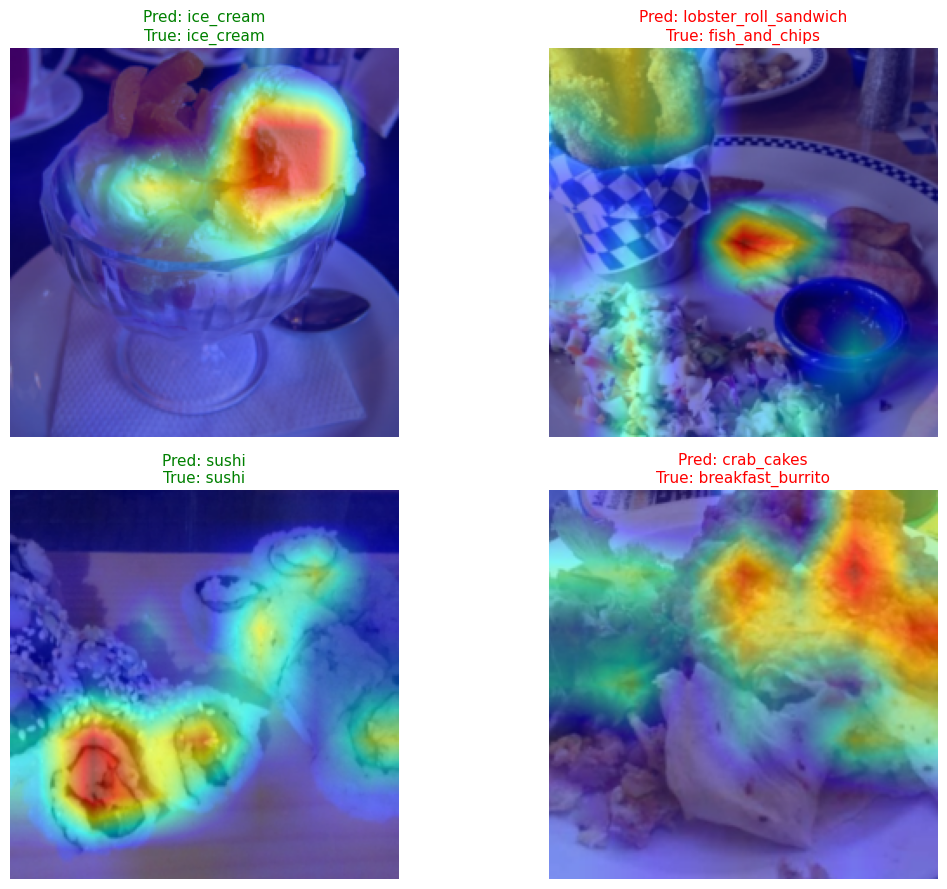

In [73]:
# Build Grad-CAM overlays separately for the correct and incorrect samples that
# were selected earlier. Here we explain the predicted class for both groups.
gradcam_examples = {
    "correct_examples": build_gradcam_examples(examples["correct_examples"], target_mode="pred"),
    "incorrect_examples": build_gradcam_examples(examples["incorrect_examples"], target_mode="pred"),
}

# Plot the stored overlays. The helper uses the metadata in each example to show
# the CAM image together with the predicted and true class names.
fig, axes = helper_utils.show_test_prediction_gradcam_examples(
    gradcam_examples,
    class_names=testset.classes,
)
